# pipekit-train — Bayesian inference (1/3): NumPyro **SVI**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/pipekit/blob/main/docs/notebooks/pipekit_train_numpyro_svi.ipynb)

`pipekit-train` makes **Bayesian inference a first-class `TrainingLoop`
target**: you write a probabilistic model once and fit it through the same
loop you use for neural nets. This is the first of three short, runnable
examples that all fit the *same* Bayesian linear-regression model with a
different inference engine:

| # | Notebook | Backend | Paradigm |
|---|----------|---------|----------|
| **1** | **this one** | `numpyro-svi` | **variational** (a per-step optimizer) |
| 2 | `pipekit_train_numpyro_mcmc` | `numpyro-mcmc` | **sampling** — NUTS (one blocking run) |
| 3 | `pipekit_train_blackjax` | `blackjax` | **sampling** — NUTS via a sampler library |

This notebook covers **Stochastic Variational Inference (SVI)**: it
approximates the posterior with a parametric family and maximises a lower
bound by gradient ascent — so it really *is* the per-step `TrainingLoop`
(optimizer config, metric logging, early stopping all apply).

See the design note
[`numpyro_adapter.md`](../design-train/numpyro_adapter.md) (ADR **D13**) for
the full rationale.

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "pipekit-train[numpyro] @ git+https://github.com/jejjohnson/pipekit@main#subdirectory=packages/pipekit-train",
            "pipekit @ git+https://github.com/jejjohnson/pipekit@main#subdirectory=packages/pipekit",
        ],
        check=True,
    )

In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from numpyro.infer.autoguide import AutoNormal
from pipekit import Identity
from pipekit_train import IterableDataset, JSONLWriter, TrainingLoop
from pipekit_train.adapters._bayes import NumpyroTask

/home/user/pipekit/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Reproducibility readout — version metadata for the committed outputs.
import importlib.util


try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic(
        "watermark",
        "-v -m -p numpy,jax,numpyro,optax,pipekit,pipekit_train",
    )
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.12.3
IPython version      : 9.10.0

numpy        : 2.4.4
jax          : 0.10.1
numpyro      : 0.21.0
optax        : 0.2.8
pipekit      : 0.0.1
pipekit_train: 0.0.1

Compiler    : GCC 13.3.0
OS          : Linux
Release     : 6.18.5
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit



## 1. The problem — Bayesian linear regression

We observe pairs $(x_i, y_i)$ generated by a noisy line. The **generative
model** places priors on a slope $w$, intercept $b$, and noise scale
$\sigma$, with a Gaussian likelihood:

$$
w \sim \mathcal{N}(0, 5), \quad
b \sim \mathcal{N}(0, 5), \quad
\sigma \sim \mathrm{HalfNormal}(1),
$$

$$
y_i \mid x_i, w, b, \sigma \;\sim\; \mathcal{N}\!\bigl(w\,x_i + b,\; \sigma^2\bigr).
$$

The target is the **posterior** $p(w, b, \sigma \mid \mathbf{x}, \mathbf{y})
\propto p(\mathbf{y} \mid \mathbf{x}, w, b, \sigma)\,p(w)\,p(b)\,p(\sigma)$.
We synthesise data from the true line $y = 2x + 1$ with small noise, so a
correct inference should concentrate the posterior near $w=2$, $b=1$.

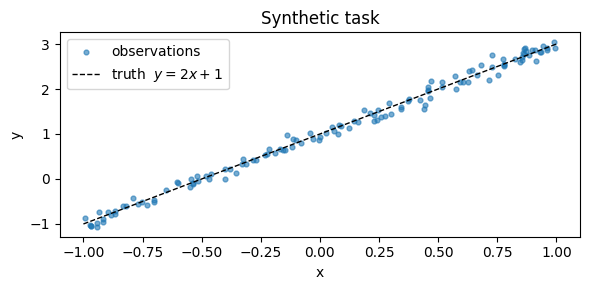

In [4]:
rng = np.random.default_rng(0)
n = 128
xs = rng.uniform(-1.0, 1.0, size=(n, 1)).astype(np.float32)
ys = (2.0 * xs[:, 0] + 1.0 + 0.1 * rng.standard_normal(n)).astype(np.float32)

plt.figure(figsize=(6, 3))
plt.scatter(xs[:, 0], ys, s=12, alpha=0.6, label="observations")
plt.plot([-1, 1], [2 * -1 + 1, 2 * 1 + 1], "k--", lw=1, label="truth  $y=2x+1$")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Synthetic task")
plt.tight_layout()
plt.show()

## 2. Wrap as a `TrainingDataset`

`IterableDataset` is the generic escape hatch — any iterable of
`(input, target)` pairs. The SVI backend is **full-batch** in v1: it
materialises the whole dataset and evaluates the ELBO on all of it each
step (minibatch SVI via `numpyro.plate(subsample_size=…)` is a documented
follow-on).

In [5]:
pairs = list(zip(xs, ys, strict=True))
dataset = IterableDataset(source=pairs, content_hash=f"linreg-{n}")

## 3. The probabilistic model

A NumPyro model is a plain Python callable using `numpyro.sample`. The
`obs=y` keyword conditions the likelihood site on data when `y` is given,
and leaves it free (for prediction) when `y is None`.

In [6]:
def model(x, y=None):
    w = numpyro.sample("w", dist.Normal(0.0, 5.0))
    b = numpyro.sample("b", dist.Normal(0.0, 5.0))
    sigma = numpyro.sample("sigma", dist.HalfNormal(1.0))
    mu = w * x[..., 0] + b
    numpyro.sample("obs", dist.Normal(mu, sigma), obs=y)  # likelihood site

## 4. The inference method — SVI / the ELBO

SVI picks a parametric **guide** $q_\phi(w, b, \sigma)$ and maximises the
**evidence lower bound**

$$
\mathrm{ELBO}(\phi)
= \mathbb{E}_{q_\phi}\!\bigl[\log p(\theta, \mathbf{y} \mid \mathbf{x}) - \log q_\phi(\theta)\bigr]
\;\le\; \log p(\mathbf{y} \mid \mathbf{x}),
\qquad \theta = (w, b, \sigma).
$$

Maximising the ELBO minimises $\mathrm{KL}\!\left(q_\phi \,\|\, p(\theta \mid
\mathbf{x}, \mathbf{y})\right)$, so $q_\phi$ converges to the posterior. This
is a **gradient-ascent loop** in $\phi$ — exactly the per-step
`TrainingLoop`. We use `AutoNormal`, the mean-field Gaussian guide (a
diagonal Normal over the unconstrained parameters — automatic differentiation
variational inference, ADVI).

## 5. Fit through the `TrainingLoop`

The backend is **task-first**: the objective is the model's ELBO, not a
carrier-agnostic `Loss(pred, target)`, so we pass a `NumpyroTask` as
`loop.task`. `model_op` is required by the loop but **ignored** here (the
task carries the model) — we pass `Identity()`. The `optimizer_config` is
translated to an optax optimiser and handed to NumPyro's `SVI`.

In [7]:
task = NumpyroTask(
    model,
    guide=AutoNormal(model),
    predictive_site="obs",
    predictive_samples=400,
)

writer = JSONLWriter(path="svi_metrics.jsonl", flush_every=1)

loop = TrainingLoop(
    model_op=Identity(),  # ignored; the task carries the model
    dataset=dataset,
    backend="numpyro-svi",
    task=task,
    optimizer_config={"name": "adam", "lr": 1e-2},
    max_steps=800,
    metric_writer=writer,
    log_every_n_steps=1,
    seed=0,
)

`TrainingLoop.run()` returns `(trained_model_op, artifact)`. The first call
JIT-compiles the per-step `svi.update`; subsequent steps reuse it.

In [8]:
svi_op, artifact = loop.run()

info = artifact.backend_info
print(f"Backend     : {info['backend']}")
print(f"Guide       : {info['guide']}")
print(f"Steps       : {info['final_step']}")
print(f"Final ELBO   : {info['final_elbo']:.2f}")
print(f"Param shapes: {info['param_shapes']}")

Backend     : numpyro-svi
Guide       : AutoNormal
Steps       : 800
Final ELBO   : 87.39
Param shapes: {'b_auto_loc': [], 'b_auto_scale': [], 'sigma_auto_loc': [], 'sigma_auto_scale': [], 'w_auto_loc': [], 'w_auto_scale': []}


## 6. The ELBO curve

The metric writer logged `elbo` (and `loss = -elbo`) every step. A rising,
plateauing ELBO is the variational analogue of a falling training loss.

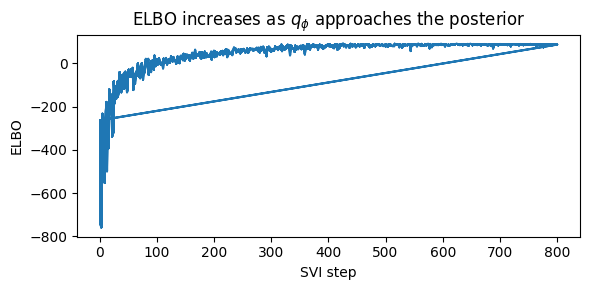

In [9]:
import json


with open("svi_metrics.jsonl") as f:
    records = [json.loads(line) for line in f]
steps = [r["step"] for r in records]
elbo = [r["metrics"]["elbo"] for r in records]

plt.figure(figsize=(6, 3))
plt.plot(steps, elbo)
plt.xlabel("SVI step")
plt.ylabel("ELBO")
plt.title("ELBO increases as $q_\\phi$ approaches the posterior")
plt.tight_layout()
plt.show()

## 7. The trained operator — posterior predictive

`svi_op` is an ordinary `pipekit.Operator`. Calling it returns the
**posterior-predictive mean** of the `obs` site,

$$
\mathbb{E}[y^\ast \mid x^\ast, \text{data}]
\;\approx\; \frac{1}{S}\sum_{s=1}^{S} \bigl(w^{(s)} x^\ast + b^{(s)}\bigr),
\qquad \theta^{(s)} \sim q_\phi,
$$

averaging over $S$ draws from the fitted guide. We also reach into the
wrapped `numpyro.infer.Predictive` (`svi_op.predictive`) to draw the full
predictive distribution and shade a 95% band — these draws include the
observation noise $\sigma$.

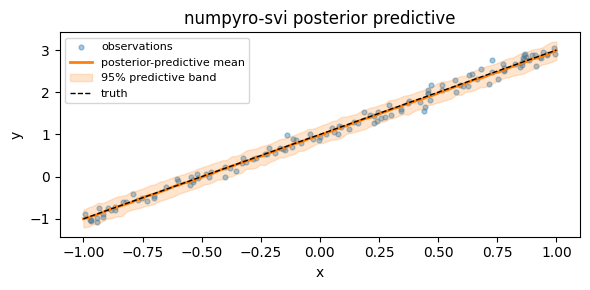

In [10]:
x_grid = jnp.linspace(-1.0, 1.0, 100).reshape(-1, 1)

# point prediction — the Operator call
y_mean = np.asarray(svi_op(x_grid))

# full predictive draws for an uncertainty band (the wrapped Predictive)
draws = svi_op.predictive(jax.random.key(1), x_grid)["obs"]
lo, hi = np.percentile(np.asarray(draws), [2.5, 97.5], axis=0)

plt.figure(figsize=(6, 3))
plt.scatter(xs[:, 0], ys, s=12, alpha=0.4, label="observations")
plt.plot(x_grid[:, 0], y_mean, "C1", lw=2, label="posterior-predictive mean")
plt.fill_between(
    x_grid[:, 0], lo, hi, color="C1", alpha=0.2, label="95% predictive band"
)
plt.plot([-1, 1], [-1, 3], "k--", lw=1, label="truth")
plt.xlabel("x")
plt.ylabel("y")
plt.legend(fontsize=8)
plt.title("numpyro-svi posterior predictive")
plt.tight_layout()
plt.show()

## 8. The artifact & registry round-trip

`TrainingArtifact` is the reproducibility record. The trained operator's
**weight blob** is the variational-parameter PyTree (`svi_op.posterior`) —
`serialize_weights()` persists it for a `ModelRegistry`, exactly like a
trained neural net (`pipekit-jax.JaxModelOp`).

In [11]:
params = {k: tuple(np.shape(v)) for k, v in svi_op.posterior.items()}
print("Variational params:", params)
print("Weight-blob bytes :", len(svi_op.serialize_weights()))

# Both the experiment-backed and the local fallback artifact are dataclasses,
# so `dataclasses.asdict` serialises either; `pipekit-train[experiment]` adds
# native `artifact.save(...)` + model-registry integration on top.
import dataclasses
import json


with open("svi_artifact.json", "w") as f:
    json.dump(dataclasses.asdict(artifact), f, indent=2, default=str)
print("Saved svi_artifact.json — the run is reproducible.")

Variational params: {'b_auto_loc': (), 'b_auto_scale': (), 'sigma_auto_loc': (), 'sigma_auto_scale': (), 'w_auto_loc': (), 'w_auto_scale': ()}
Weight-blob bytes : 312
Saved svi_artifact.json — the run is reproducible.


### What's next

- **Notebook 2 — `numpyro-mcmc`**: the *exact* (asymptotically unbiased)
  posterior via NUTS, with the **same `NumpyroTask`** — flip the backend
  string. It plots the full posterior over $w, b$ that SVI only approximates.
- **Notebook 3 — `blackjax`**: the same NumPyro model sampled by a *different
  engine* (BlackJAX NUTS), showing the shared `_bayes` seam.

In [12]:
# Clean up the demo files.
import os


for path in ("svi_metrics.jsonl", "svi_artifact.json"):
    if os.path.exists(path):
        os.remove(path)